<a href="https://colab.research.google.com/github/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar/blob/main/entornos_complejos/src/lunar_SARSAsemiSA.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
#@title Copiar el repositorio.
print("Clonando el repositorio, tiempo estimado: 1-2 minutos...")
!git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
!cd EML_Carrillo_Ibarrola_Palomar/

#@title Importamos todas las clases y funciones
import sys
# Añadir los directorio fuentes al path de Python
sys.path.append('/content/EML_Carrillo_Ibarrola_Palomar/entornos_complejos/src/')
# Verificar que se han añadido correctamente
print(sys.path)

!pip install -r ./EML_Carrillo_Ibarrola_Palomar/requirements.txt

dir_base = "./EML_Carrillo_Ibarrola_Palomar/entornos_complejos"

In [ ]:
from tqdm import tqdm
import random
import numpy as np
import gymnasium as gym
from agents import StateAggregationEnv, LunarAgentSARSA

random.seed(42)
np.random.seed(42)

In [ ]:

def train_agent_SARSA(agent, n_episodes, saving=False):  
    env = agent.env

    for n in tqdm(range(n_episodes)):
        obs, info = env.reset()
        done = False

        # Play one complete episode
        action = agent.get_action(obs)                            
        
        while not done:
            next_obs, reward, terminated, truncated, info = env.step(action)        

            next_action = agent.get_action(next_obs)                  

            # Update Q-values (Semigradient SARSA)
            agent.update(obs, action, reward, terminated, next_obs, next_action)    

            # Move to next state
            done = terminated or truncated
            obs = next_obs
            action = next_action

        # Reduce exploration rate (agent becomes less random over time)
        agent.decay_epsilon()

(4, 4, 4, 4, 4, 4, 2, 2, 4)


100%|██████████| 20000/20000 [04:17<00:00, 77.76it/s]


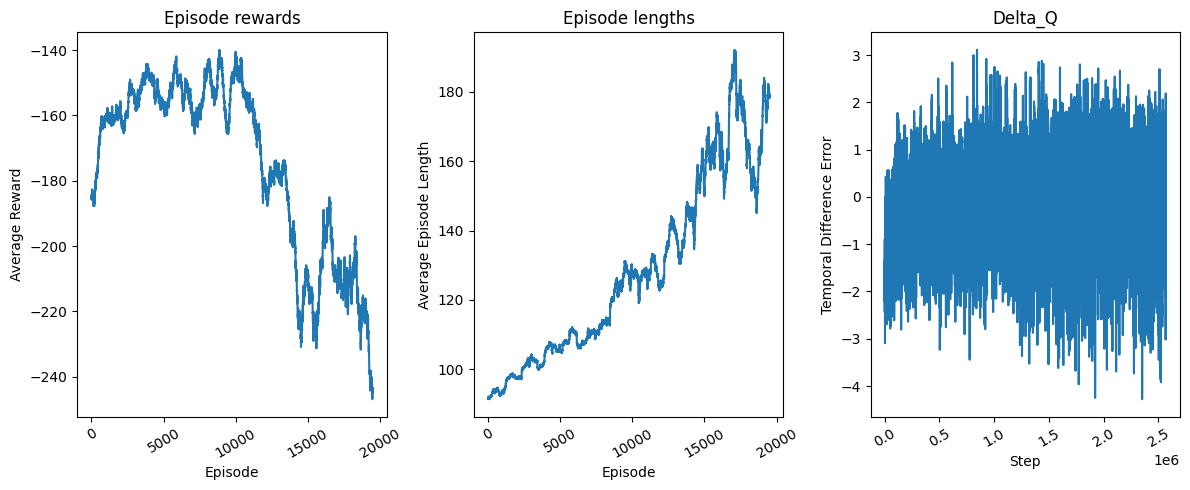

In [ ]:

# ----- CONFIGURACIÓN Y EJECUCIÓN -----

learning_rate, n_episodes = (0.2, 20000) # LunarLander puede necesitar bastantes episodios

# # Creamos el entorno original y lo envolvemos en nuestro Tile Coder
# base_env = gym.make("LunarLander-v3")
# # 4 bins por cada una de las 8 dimensiones
bins = np.array([4, 4, 4, 4, 4, 4, 2, 2])  # número de intervalos por dimensión
n_tilings = 4
# env = LunarLanderTileCoding(base_env, bins=bins, n_tilings=8)

# # Utilizamos RecordEpisodeStatistics para el tracking (requiere acceder a env.unwrapped.return_queue)
# env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

initial_epsilon = 1.0
final_epsilon = 0.05
ratio = 0.8 # Exploramos durante el 80% del entrenamiento

# agent = LunarAgentSARSA(
#     env=env,
#     learning_rate=learning_rate,
#     initial_epsilon=initial_epsilon,
#     epsilon_decay=(initial_epsilon - final_epsilon) / (n_episodes * ratio),
#     final_epsilon=final_epsilon,
#     decay_type="linear"
# )
base_env = gym.make("LunarLander-v3")
saenv = StateAggregationEnv(base_env, bins=bins, low=base_env.observation_space.low, high=base_env.observation_space.high, n_tilings = n_tilings)
saenv = gym.wrappers.RecordEpisodeStatistics(saenv, buffer_length=n_episodes)
saenv.bins = bins
saenv.n_tilings = n_tilings
# 4. Envolvemos para estadísticas
#env = gym.wrappers.RecordEpisodeStatistics(saenv, buffer_length=n_episodes)

# 5. Pasamos el entorno al agente
# El agente ahora podrá acceder a n_tilings si lo modificamos ligeramente 
# o si usamos las variables que ya extrajimos.
agent = LunarAgentSARSA(
    env=saenv,
    learning_rate=learning_rate,
    initial_epsilon=initial_epsilon,
    epsilon_decay=(initial_epsilon - final_epsilon) / (n_episodes * ratio),
    final_epsilon=final_epsilon,
    decay_type="linear"
)

saved_episodes = train_agent_SARSA(agent, n_episodes, saving=True)

import utils
utils.plot_training_metrics(saenv.return_queue, saenv.length_queue, agent.training_error, rolling_length=500)


In [3]:
import gymnasium as gym
import numpy as np

def visualize_solution(agent, env_name="LunarLander-v3", bins=None, seed=None):
    # Creamos el entorno base con render
    base_env = gym.make(env_name, render_mode="human")
    
    # Envolvemos con Tile Coding si bins fueron proporcionados
    if bins is not None:
        # Extraemos los límites del espacio de observación del entorno base
        low = base_env.observation_space.low
        high = base_env.observation_space.high
        
        # Pasamos low, high, y usamos 'n' en lugar de 'n_tilings'
        tile_env = StateAggregationEnv(base_env, bins=bins, low=low, high=high)
    else:
        tile_env = base_env  # si no usamos Tile Coding

    # Recordamos estadísticas (opcional)
    env = gym.wrappers.RecordEpisodeStatistics(tile_env, buffer_length=1)
    
    obs, info = env.reset(seed=seed)
    done = False
    total_reward = 0
    step_count = 0
    
    while not done:
        # obs ya está en formato Tile Coding si usamos tile_env
        action = agent.get_action(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        step_count += 1

    print(f"Total reward del episodio visualizado: {total_reward:.2f}")
    env.close()

# ----- USO -----
# Reutiliza los bins y n_tilings que usaste para entrenar
visualize_solution(agent, bins=bins)

Total reward del episodio visualizado: -100.79


In [4]:
agent.test()

Test Results over 1000 episodes:
Win Rate: 0.0%
Average Reward: -194.165
Standard Deviation: 143.337


(np.float64(0.0),
 np.float64(-194.16458449620686),
 np.float64(143.336862177403))

In [ ]:
import imageio
import base64
from IPython.display import HTML
def run_episode_greedy_lunarlander(agent, env, max_steps=1000):
    frames = []
    obs, _ = env.reset()
    agent.epsilon = 0.0  # Forzamos a ser completamente greedy
    
    for _ in range(max_steps):
        frame = env.render()
        frames.append(frame)

        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        obs = next_obs
        
        if terminated or truncated:
            frames.append(env.render())
            break

    return frames

def frames_to_gif(frames, filename=dir_base+"/data/results/SARSAsemi/lunarlander_sarsa.gif"):
    with imageio.get_writer(filename, mode='I') as writer:
        for frame in frames:
            writer.append_data(frame)
    return filename

def display_gif(gif_path):
    with open(gif_path, 'rb') as f:
        video = f.read()
    b64 = base64.b64encode(video)
    return HTML(f'<img src="data:image/gif;base64,{b64.decode()}" />')

GIF guardado en: lunarlander_sarsa2.gif



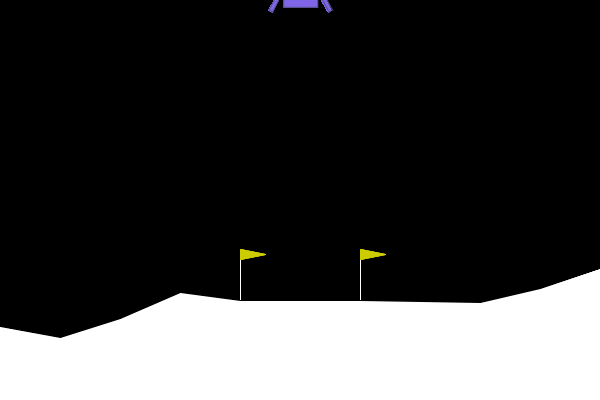

In [ ]:
# Crear entorno con modo render para capturar imágenes
env_demo = gym.make("LunarLander-v3", render_mode='rgb_array')
env_demo = StateAggregationEnv(env_demo, bins=np.array([4,4,4,4,4,4,2,2]), low=env_demo.observation_space.low, high=env_demo.observation_space.high)
state_dim = env_demo.observation_space.shape[0]
action_dim = env_demo.action_space.n

# Ejecutar episodio greedy
frames = run_episode_greedy_lunarlander(agent, env_demo, max_steps=1000)

env_demo.close()

# Crear GIF
gif_path = frames_to_gif(frames, filename=dir_base+"/data/results/SARSAsemi/lunarlander_sarsa2.gif")
print("GIF guardado en:", gif_path)

# Mostrar GIF
display_gif(gif_path)